In [1]:
import warnings
# warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import json
import pandas as pd
import datetime
today = datetime.date.today()
import pickle
import arviz as az
from arviz.utils import get_coords, _var_names

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)
from flonacomldft.models.mixture import Mixture

from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)
from ase.units import kB

beta = 1.0 / (kB * 350)
mode_labels = [0, 1]

In [2]:
T = 350
kBT_in_eV = kB * T
kBT_in_eV

0.030160656180260245

In [3]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

### 0.1 - Dataframe with all the args of the simulations

In [4]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
subproject_path = project_path + '/adaptive-350/20231911_adaptive_single_isomer/'

os.listdir(subproject_path)

dic_args = {}

In [5]:
##### MD simulations
isomers = [0]*4 + [1]*4
flows_ids = [int('3006479{:d}'.format(i)) for i in range(8)]
samples_ids = [int('3006662{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '3-flows-md/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training'] = df_args

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, samples_ids):
    args_file = 'args_samples_from_flow_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-sampling'] = df_args

### new MD simulations
isomers = [0]*9 + [1]*9
flows_ids = ['3077978'+str(i) for i in range(0, 18)]

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:s}.json'.format(number_id)
    f = open(subsubproject_path+'results_flow_is{:d}_{:s}/'.format(isomer_id,number_id)+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training-2212'] = df_args

/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_16268/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_16268/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_16268/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_16268/3064257333.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_

In [6]:

##### ab-flowMC w.o. NP
isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('2994169{:d}'.format(i)) for i in range(8)] + [int('2994949{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '/1-adaptive/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, number_ids):
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data)
    df_args = df_args.append(sub_df)

dic_args['ab-flowMC-wo-NP'] = df_args

##### ab-flowMC 

isomers = [0]*4 + [1]*4
number_ids = [int('3000710{:d}'.format(i)) for i in range(8)]
subsubproject_path = subproject_path + '/2-adaptive-mlp/'
# project_path = project_path_ + '/2-adaptive-mlp/'

isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('3001962{:d}'.format(i)) for i in range(8)] + [int('3000710{:d}'.format(i)) for i in range(8)]

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, number_ids):
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data)
    df_args = df_args.append(sub_df)

dic_args['ab-flowMC'] = df_args


/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_16268/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_16268/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_16268/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_16268/3634886719.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_

## 1.z - Mixture MCMC populations

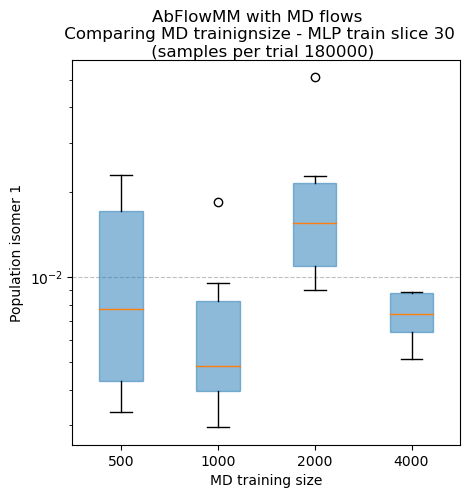

In [8]:
import matplotlib.patches as mpatches

# plot boxplots of ratio of partition functions
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-07-MD-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 1000, 2000, 4000]
flow_train_slices = [0] #, 12, 18, 24, 30]
mlp_train_slices = [30] #[0]
sample_size = 180000

plt.figure(figsize=(5, 5))
handles = []
# axs = [plt.subplot(1, 3, i+1) for i in range(3)]
ax = plt.subplot(111)
plt.suptitle('AbFlowMM with MD flows \n Comparing MD trainignsize - MLP train slice {:d} \n (samples per trial {:d})'.format(mlp_train_slice, sample_size))

# AbFlowMM results - flow training slice -1

for f,flow_train_slice in enumerate(flow_train_slices):
    pop_isomer_1s = []
    labels = []
    for md_training_size in md_training_sizes:
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))
    
        labels.append('{:d}'.format(md_training_size))
        df_md = df.loc[df['kind'] == 'MD']
        df_md = df_md.loc[df_md['md_training_size'] == md_training_size]
        df_md = df_md.loc[df_md['flow_train_slice'] == flow_train_slice]
        df_md = df_md.loc[df_md['sample_size'] == sample_size]

        pop_isomer_1 = df_md['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        
        
    # plt.sca(axs[0])
    # plt.title('- FE isomer 0'.format(sample_size))
    # plt.boxplot(pop_isomer_1, labels=labels,
    #             patch_artist = True,
    #             boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2)),)
    # plt.xlabel('flow training slice')
    # axs[0].set_axisbelow(True)
    # axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    
    plt.sca(ax)
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(f), color = "C{:d}".format(f), alpha=0.5),
                )
    # red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d}'.format(md_training_size))
    # handles.append(red_patch)

    plt.xlabel('MD training size')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    plt.yscale('log')
    plt.ylabel('Population isomer 1')

    # plt.sca(axs[2])
    # plt.title('Ratio Z_0 / Z_1 ')
    # plt.boxplot(zrs, labels=labels,
    #             # patch_artist = True,
    #             # boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2)),)
    # plt.xlabel('flow training slice')
    # axs[2].set_axisbelow(True)
    # axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

# plt.legend(handles=handles)
# plt.tight_layout()
# plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

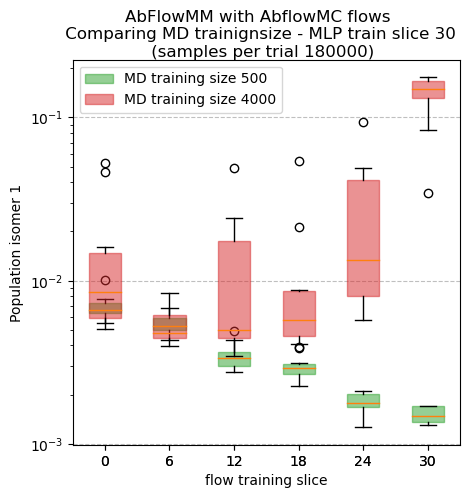

In [9]:
import matplotlib.patches as mpatches

# plot boxplots of ratio of partition functions
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-07-abmc-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 180000	
flow_train_slices = [0, 6, 12, 18, 24, 30]

plt.figure(figsize=(5, 5))
handles = []
# axs = [plt.subplot(1, 3, i+1) for i in range(3)]
ax = plt.subplot(111)
plt.suptitle('AbFlowMM with AbflowMC flows \n Comparing MD trainignsize - MLP train slice {:d} \n (samples per trial {:d})'.format(mlp_train_slice, sample_size))

# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    pop_isomer_1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        pop_isomer_1 = df_abflow['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        
        
    # plt.sca(axs[0])
    # plt.title('- FE isomer 0'.format(sample_size))
    # plt.boxplot(pop_isomer_1, labels=labels,
    #             patch_artist = True,
    #             boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2)),)
    # plt.xlabel('flow training slice')
    # axs[0].set_axisbelow(True)
    # axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    
    plt.sca(ax)
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d}'.format(md_training_size))
    handles.append(red_patch)

    plt.xlabel('flow training slice')
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    plt.yscale('log')
    plt.ylabel('Population isomer 1')

    # plt.sca(axs[2])
    # plt.title('Ratio Z_0 / Z_1 ')
    # plt.boxplot(zrs, labels=labels,
    #             # patch_artist = True,
    #             # boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2)),)
    # plt.xlabel('flow training slice')
    # axs[2].set_axisbelow(True)
    # axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

plt.legend(handles=handles)
# plt.tight_layout()
# plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

# 2 - deepBAR

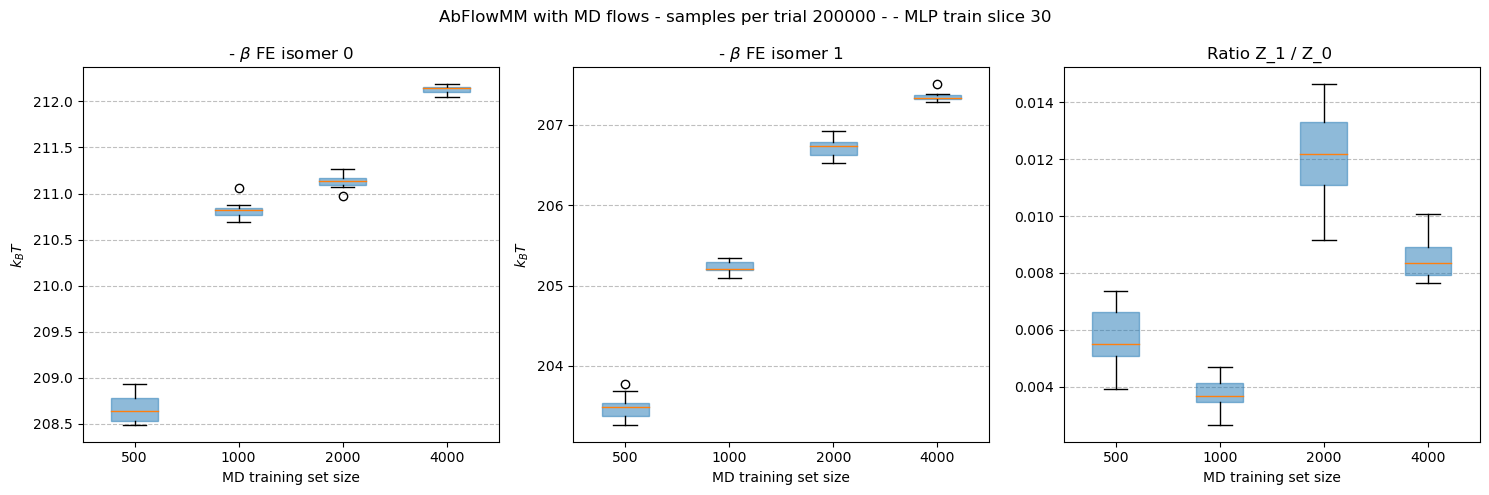

In [10]:
# plot boxplots of ratio of partition functions
mlp_train_slice = 30

filename = subproject_path + '9-mcmc-bar/2023-12-05-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 1000, 2000, 4000]
sample_size = 200000
flow_train_slices =[0]

zrs = []
z0s = []
z1s = []
labels = []


plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 3, i+1) for i in range(3)]
plt.suptitle('AbFlowMM with MD flows - samples per trial {:d} - - MLP train slice {:d}'.format(sample_size, mlp_train_slice))


for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

        
plt.sca(axs[0])
plt.title(r'- $\beta$ FE isomer 0'.format(sample_size))
plt.boxplot(z0s, labels=labels,
            patch_artist = True,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            )
plt.xlabel('MD training set size')
axs[0].set_axisbelow(True)
axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
axs[0].set_ylabel(r'$k_B T$')

plt.sca(axs[1])
plt.title(r'- $\beta$ FE isomer 1'.format(sample_size))
plt.boxplot(z1s, labels=labels,
            patch_artist = True,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            )
plt.xlabel('MD training set size')
axs[1].set_axisbelow(True)
axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
axs[1].set_ylabel(r'$k_B T$')

plt.sca(axs[2])
plt.title('Ratio Z_1 / Z_0 ')
plt.boxplot(zrs, labels=labels,patch_artist = True,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            )
plt.xlabel('MD training set size')
axs[2].set_axisbelow(True)
axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

plt.tight_layout()
plt.savefig(filename + '.png', dpi=300)

### 3.2.2 - Adaptive flows

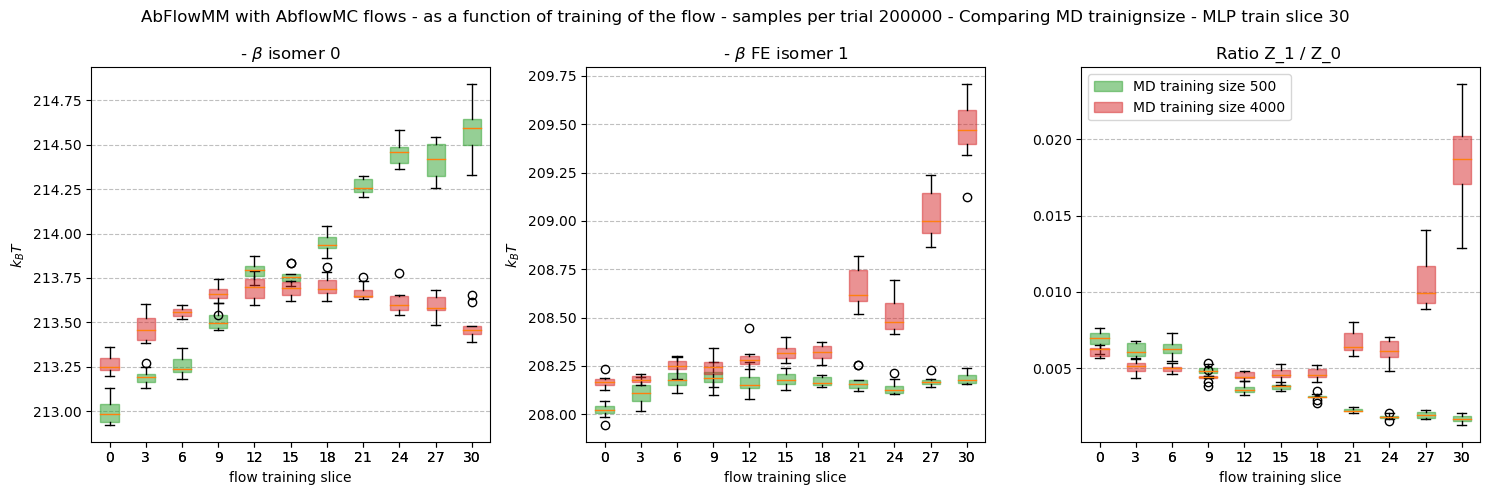

In [11]:
# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 200000
flow_train_slices = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 3, i+1) for i in range(3)]
plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainignsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []
# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    plt.sca(axs[0])
    plt.title(r'- $\beta$ isomer 0'.format(sample_size))
    plt.boxplot(z0s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
               
    plt.xlabel('flow training slice')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[0].set_ylabel(r'$k_B T$')
    
    plt.sca(axs[1])
    plt.title(r'- $\beta$ FE isomer 1'.format(sample_size))
    plt.boxplot(z1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[1].set_ylabel(r'$k_B T$')

    plt.sca(axs[2])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[2].set_axisbelow(True)
    axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d}'.format(md_training_size))
    handles.append(red_patch)

plt.legend(handles=handles)
plt.tight_layout()
plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

## 4 - Putting MCMC + BAR together for the relative populations

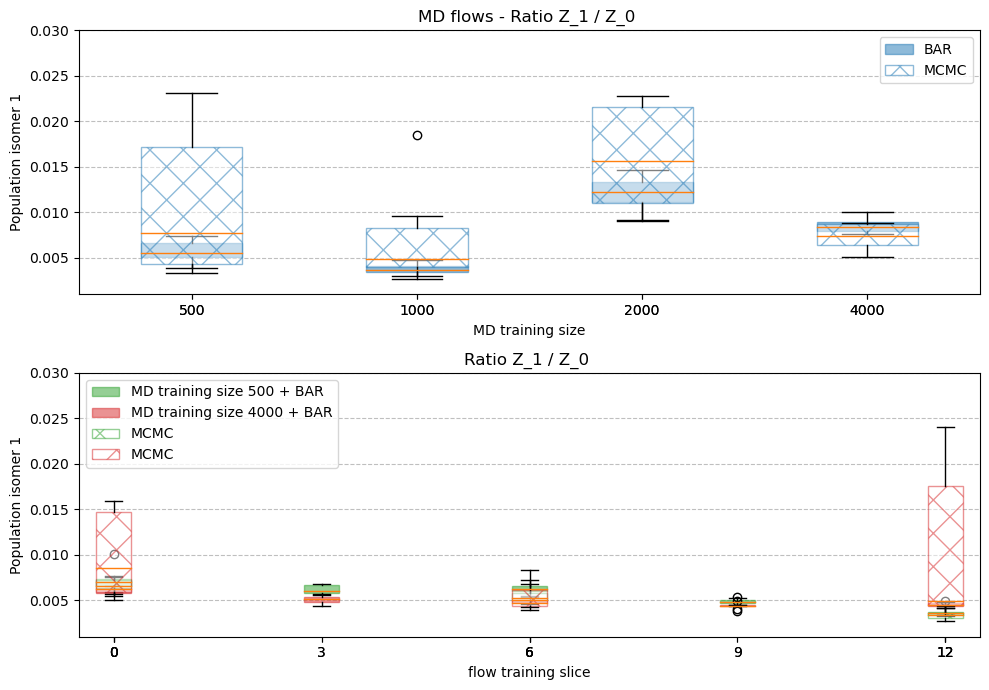

In [54]:
plt.figure(figsize=(10, 7))
axs = [plt.subplot(211),plt.subplot(212)]
# plt.suptitle('AbFlowMM with MD flows - samples per trial {:d} - - MLP train slice {:d}'.format(sample_size, mlp_train_slice))


### MD FLOWS BAR
handles = []
# plot boxplots of ratio of partition functions
mlp_train_slice = 30

filename = subproject_path + '9-mcmc-bar/2023-12-05-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 1000, 2000, 4000]
sample_size = 200000
flow_train_slices =[0]

zrs = []
z0s = []
z1s = []
labels = []


for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

plt.sca(axs[0])
plt.title('MD flows - Ratio Z_1 / Z_0 ')
plt.boxplot(zrs, labels=labels,patch_artist = True,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            )
plt.xlabel('MD training set size')
axs[0].set_axisbelow(True)
axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

red_patch = mpatches.Patch(color = "C0".format(m+2), alpha=0.5, label='BAR')
handles.append(red_patch)


## MD Flows MCMCs

mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-07-MD-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 1000, 2000, 4000]
flow_training_slices = [0] #, 12, 18, 24, 30]
mlp_train_slices = [30] #[0]
sample_size = 180000


for f,flow_train_slice in enumerate(flow_train_slices):
    pop_isomer_1s = []
    labels = []
    for md_training_size in md_training_sizes:
     
        labels.append('{:d}'.format(md_training_size))
        df_md = df.loc[df['kind'] == 'MD']
        df_md = df_md.loc[df_md['md_training_size'] == md_training_size]
        df_md = df_md.loc[df_md['flow_train_slice'] == flow_train_slice]
        df_md = df_md.loc[df_md['sample_size'] == sample_size]

        pop_isomer_1 = df_md['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        
    
    plt.sca(axs[0])
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels,
                patch_artist = True,
                boxprops = dict(facecolor = "w", color = "C{:d}".format(f), hatch = 'x', alpha=0.5),
                )
    red_patch = mpatches.Patch(facecolor = "w", edgecolor = "C{:d}".format(f), hatch = 'x', alpha=0.5, label='MCMC')
    handles.append(red_patch)

    plt.xlabel('MD training size')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    # plt.yscale('log')
    plt.ylabel('Population isomer 1')
    plt.ylim(1e-3, 3e-2)


plt.legend(handles=handles)

##############################################################
#### ABMC FLOWS BAR

# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 200000
flow_train_slices = [0, 3, 6, 9, 12] #, 15, 18, 21, 24, 27, 30]

handles = []
# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    plt.sca(axs[1])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, labels=labels, positions=flow_train_slices,
                patch_artist = True,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                )
    plt.xlabel('flow training slice')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='MD training size {:d} + BAR'.format(md_training_size))
    handles.append(red_patch)


###### ABMC FLOWS MCMC
import matplotlib.patches as mpatches

# plot boxplots of ratio of partition functions
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-07-abmc-flows-mixture-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 180000	
flow_train_slices = [0, 6, 12]  #, 18, 24, 30]

# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    pop_isomer_1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        pop_isomer_1 = df_abflow['pop_isomer_1'].values
        pop_isomer_1s.append(pop_isomer_1)
        

    plt.sca(axs[1])
    # plt.title('- FE isomer 1'.format(sample_size))
    plt.boxplot(pop_isomer_1s, labels=labels, positions=flow_train_slices,
                patch_artist = True,
                boxprops = dict(facecolor = "w", hatch='x', color = "C{:d}".format(m+2), alpha=0.5),
                )
    red_patch = mpatches.Patch(facecolor = "w", hatch='x', edgecolor = "C{:d}".format(m+2), alpha=0.5, label='MCMC')
    handles.append(red_patch)

    plt.xlabel('flow training slice')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    # plt.yscale('log')
    plt.ylabel('Population isomer 1')
    plt.ylim(1e-3, 3e-2)



plt.legend(handles=handles)
# plt.tight_layout()
# plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)

    

plt.legend(handles=handles)




plt.tight_layout()
# plt.savefig(filename + '.png', dpi=300)

# 5 - Making the figures as a function of the number of DFT evaluations

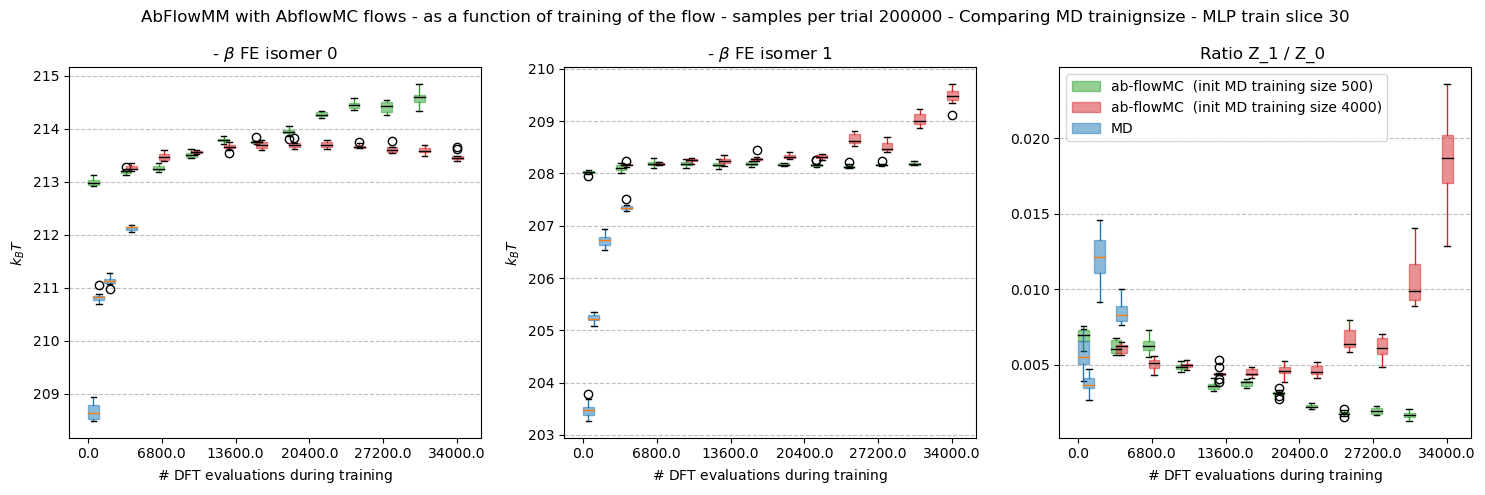

In [12]:
# plot boxplots of ratio of partition functions
import matplotlib.patches as mpatches
mlp_train_slice = 30
filename = subproject_path + '9-mcmc-bar/2023-12-05-abmc-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv') 
md_training_sizes = [500, 4000]
sample_size = 200000
flow_train_slices = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30])

plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 3, i+1) for i in range(3)]
plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - Comparing MD trainignsize - MLP train slice {:d}'.format(sample_size, mlp_train_slice))

handles = []
# AbFlowMM results - flow training slice -1
for m,md_training_size in enumerate(md_training_sizes):
    # plt.figure(figsize=(15, 5))
    # axs = [plt.subplot(1, 3, i+1) for i in range(3)]
    # plt.suptitle('AbFlowMM with AbflowMC flows - as a function of training of the flow - samples per trial {:d} - MD training size {:d} - MLP train slice {:d}'.format(sample_size, md_training_size, mlp_train_slice))

    zrs = []
    z0s = []
    z1s = []
    labels = []
    
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(flow_train_slice))
        df_abflow = df.loc[df['kind'] == 'ab-flowMC']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)
        
    plt.sca(axs[0])
    plt.title(r'- $\beta$ isomer 0'.format(sample_size))
    plt.boxplot(z0s, 
                positions=flow_train_slices * 20 * 50 + md_training_size,
                # labels=labels,
                patch_artist = True,
                widths=1000,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                whiskerprops=dict(color="C{:d}".format(m+2)),
                medianprops=dict(color='black'),
                )
               
    plt.xlabel(r'$\#$ DFT calls for training')
    axs[0].set_axisbelow(True)
    axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[0].set_ylabel(r'$k_B T$')
    plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))
    
    plt.sca(axs[1])
    plt.title(r'- $\beta$ FE isomer 1'.format(sample_size))
    box_plot = plt.boxplot(z1s, 
                positions=flow_train_slices * 20 * 50 + md_training_size,
                # labels=labels,
                patch_artist = True,
                widths=1000,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                whiskerprops=dict(color="C{:d}".format(m+2)),
                medianprops=dict(color='black'),
                )
    plt.xlabel(r'$\#$ DFT calls for training')
    axs[1].set_axisbelow(True)
    axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    axs[1].set_ylabel(r'$k_B T$')
    plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))

    plt.sca(axs[2])
    plt.title('Ratio Z_1 / Z_0 ')
    plt.boxplot(zrs, 
                positions=flow_train_slices * 20 * 50 + md_training_size,
                # labels=labels,
                patch_artist = True,
                widths=1000,
                boxprops = dict(facecolor = "C{:d}".format(m+2), color = "C{:d}".format(m+2), alpha=0.5),
                whiskerprops=dict(color="C{:d}".format(m+2)),
                medianprops=dict(color='black'),
                )
    plt.xlabel(r'$\#$ DFT calls for training')
    axs[2].set_axisbelow(True)
    axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
    plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))

    red_patch = mpatches.Patch(color = "C{:d}".format(m+2), alpha=0.5, label='ab-flowMC  (init MD training size {:d})'.format(md_training_size))
    handles.append(red_patch)

    
    
########### ADDING MD results
mlp_train_slice = 30

filename = subproject_path + '9-mcmc-bar/2023-12-05-md-flows-BAR-results-mlpmodel{:d}'.format(mlp_train_slice)
df = pd.read_csv(filename + '.csv')
md_training_sizes = [500, 1000, 2000, 4000]
sample_size = 200000
flow_train_slices =[0]

zrs = []
z0s = []
z1s = []
labels = []

for md_training_size in md_training_sizes:
    for flow_train_slice in flow_train_slices:
        labels.append('{:d}'.format(md_training_size))
        df_abflow = df.loc[df['kind'] == 'MD']
        df_abflow = df_abflow.loc[df_abflow['md_training_size'] == md_training_size]
        df_abflow = df_abflow.loc[df_abflow['flow_train_slice'] == flow_train_slice]
        df_abflow = df_abflow.loc[df_abflow['sample_size'] == sample_size]
        df_abflow = df_abflow.loc[df_abflow['mlp_train_slice'] == mlp_train_slice]

        df_abflow_0 = df_abflow.loc[(df_abflow['isomer_id'] == 0)]
        df_abflow_1 = df_abflow.loc[(df_abflow['isomer_id'] == 1)]

        log_r_0 = df_abflow_0['log_r'].values
        log_r_1 = df_abflow_1['log_r'].values

        z_r = np.exp(log_r_0 - log_r_1)
        zrs.append(z_r)

        z_0 = (-log_r_0)
        z_1 = (-log_r_1)
        z0s.append(z_0)
        z1s.append(z_1)

        
plt.sca(axs[0])
plt.title(r'- $\beta$ FE isomer 0'.format(sample_size))
plt.boxplot(z0s, 
            # labels=labels,
            positions=md_training_sizes,
            patch_artist = True,
            widths=1000,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            whiskerprops=dict(color="C0")
            )
plt.xlabel('$\#$ DFT evaluations during training')
axs[0].set_axisbelow(True)
axs[0].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
axs[0].set_ylabel(r'$k_B T$')
plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))

plt.sca(axs[1])
plt.title(r'- $\beta$ FE isomer 1'.format(sample_size))
plt.boxplot(z1s, 
            # labels=labels,
            positions=md_training_sizes,
            patch_artist = True,
            widths=1000,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            whiskerprops=dict(color="C0")
            )
plt.xlabel('$\#$ DFT evaluations during training')
axs[1].set_axisbelow(True)
axs[1].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
axs[1].set_ylabel(r'$k_B T$')
plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))

plt.sca(axs[2])
plt.title('Ratio Z_1 / Z_0 ')
plt.boxplot(zrs,
            # labels=labels,
            positions=md_training_sizes,
            patch_artist = True,
            widths=1000,
            boxprops = dict(facecolor = "C0", color = "C0", alpha=0.5),
            whiskerprops=dict(color="C0")
            )
plt.xlabel('$\#$ DFT evaluations during training')
axs[2].set_axisbelow(True)
axs[2].yaxis.grid(color='gray', linestyle='dashed', alpha=0.5)
plt.xticks(np.linspace(0, 34000, num=6), np.linspace(0, 34000, num=6))
    

blue_patch = mpatches.Patch(color = "C0", alpha=0.5, label='MD')
handles.append(blue_patch)


plt.legend(handles=handles)
plt.tight_layout()
plt.savefig(filename + '_MDtrainingsize_both.png'.format(md_training_size), dpi=300)